2D Burgers Equation

In [3]:
from sympy import Eq, solve, symbols, Function, lambdify, diff

u = symbols('u', cls=Function)
x, y, t, dt, dx, dy, v = symbols('x y t dt dx dy v')

continuous = Eq(diff(u(t, x, y), t) + u(t, x, y)*(diff(u(t, x, y), x) + diff(u(t, x, y), y)), v*(diff(u(t, x, y), x, x) + diff(u(t, x, y), y, y)))
continuous

Eq((Derivative(u(t, x, y), x) + Derivative(u(t, x, y), y))*u(t, x, y) + Derivative(u(t, x, y), t), v*(Derivative(u(t, x, y), (x, 2)) + Derivative(u(t, x, y), (y, 2))))

In [ ]:
discrete = Eq((u(t+1, x, y) - u(t, x, y))/dt + u(t, x, y)*((u(t, x, y) - u(t, x-1, y))/dx + (u(t, x, y) - u(t, x, y-1))/dy), 
v*((-2*u(t, x, y) + u(t, x-1, y) + u(t, x+1, y))/(dx*dx) + (-2*u(t, x, y) + u(t, x, y-1) + u(t, x, y+1))/(dy*dy)))
discrete

Eq(((u(t, x, y) - u(t, x, y - 1))/dy + (u(t, x, y) - u(t, x - 1, y))/dx)*u(t, x, y) + (-u(t, x, y) + u(t + 1, x, y))/dt, v*((-2*u(t, x, y) + u(t, x, y - 1) + u(t, x, y + 1))/dy**2 + (-2*u(t, x, y) + u(t, x - 1, y) + u(t, x + 1, y))/dx**2))

In [ ]:
solution = solve(discrete, u(t+1, x, y))[0]
update_burgers = lambdify([dx, dy, dt, v, u(t, x, y), u(t, x+1, y), u(t, x-1, y), u(t, x, y+1), u(t, x, y-1)], solution)
solution

(dt*dx**2*dy*(-u(t, x, y) + u(t, x, y - 1))*u(t, x, y) + dt*dx**2*v*(-2*u(t, x, y) + u(t, x, y - 1) + u(t, x, y + 1)) + dt*dx*dy**2*(-u(t, x, y) + u(t, x - 1, y))*u(t, x, y) + dt*dy**2*v*(-2*u(t, x, y) + u(t, x - 1, y) + u(t, x + 1, y)) + dx**2*dy**2*u(t, x, y))/(dx**2*dy**2)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

width = 30
height = 30
nu = width*height

dx = 1
dy = 1
dt = 0.08

def initial_conditions():
    u = np.ones(shape=(width, height))
    u[int(width/4):int(3*width/4), int(height/4):int(3*height/4)] = 2
    return u

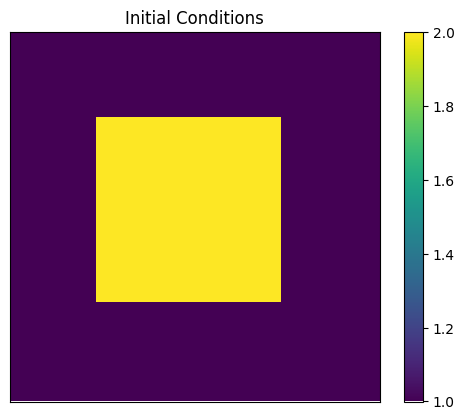

In [6]:
def plot(u, title=None):
    plt.imshow(u)
    plt.yticks([])
    plt.xticks([])
    plt.title(title)
    plt.colorbar()
    plt.show()

plot(initial_conditions(), title="Initial Conditions")

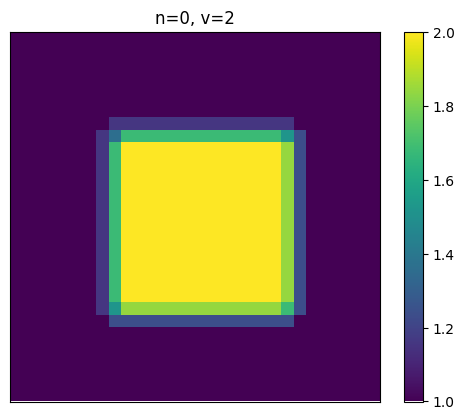

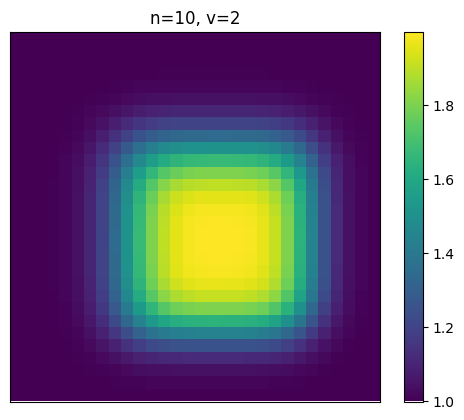

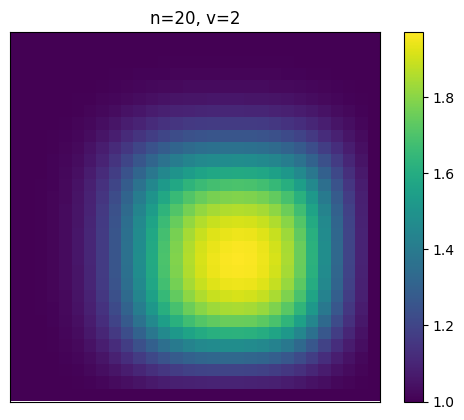

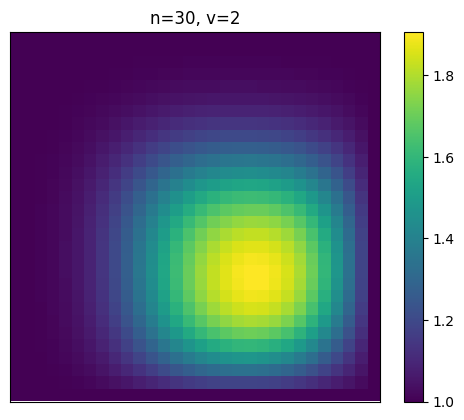

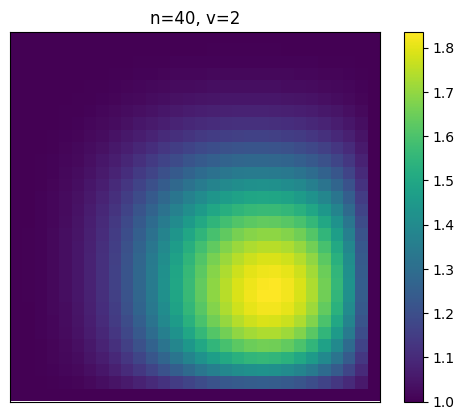

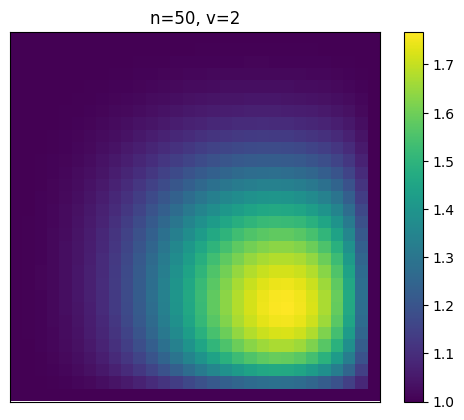

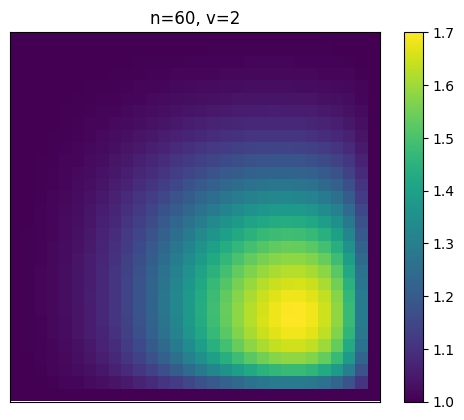

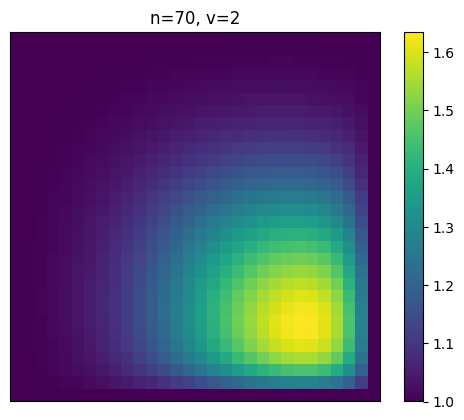

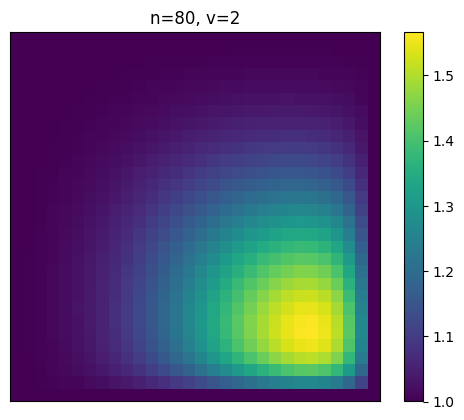

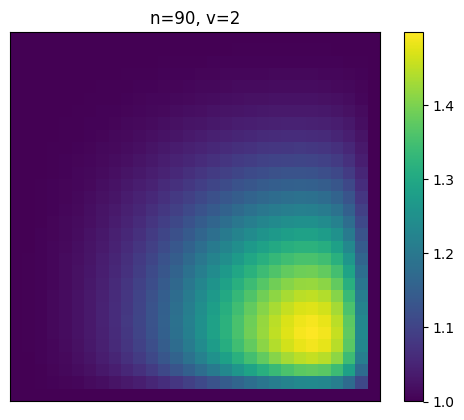

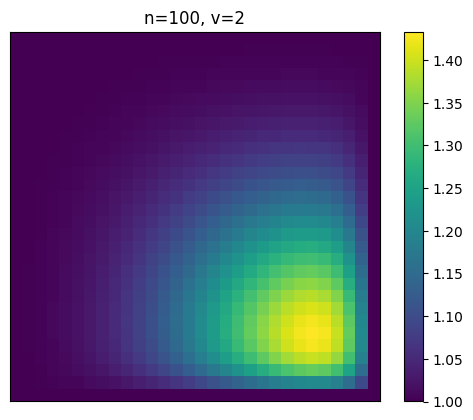

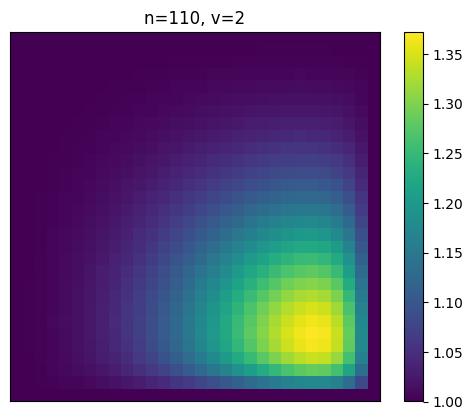

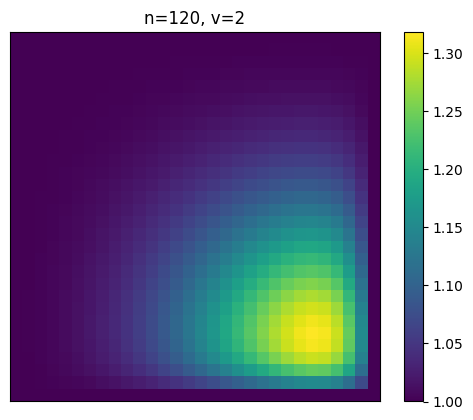

In [ ]:

def burgers(nt, v):
    u = initial_conditions()
    for n in range(nt+1):
        un = u.copy()
        for x in range(1, width-1):
            for y in range(1, height-1):
                u[x][y] = update_burgers(dx, dy, dt, v, un[x][y], un[x+1][y], un[x-1][y], un[x][y+1], un[x][y-1])
            #u[x][0] = update_burgers(dx, dy, dt, v, un[x][0], un[x+1][0], un[x-1][0], un[x][1], un[x][-1])
            #u[x][-1] = u[x][0]
        #u[0][y] = update_burgers(dx, dy, dt, v, un[0][y], un[1][y], un[-1][y], un[0][y+1], un[0][y-1])
        #u[-1][y] = u[0][y]

        if n % 10 == 0:
            plot(u, title=f"n={n}, v={v}")

burgers(120, 2)

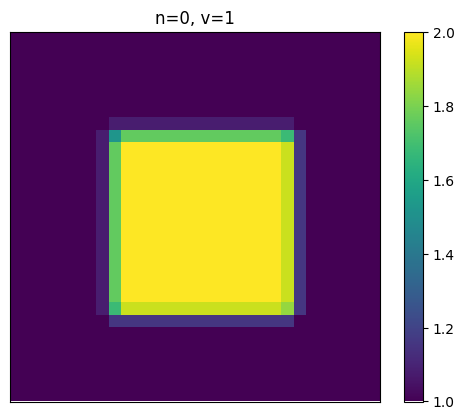

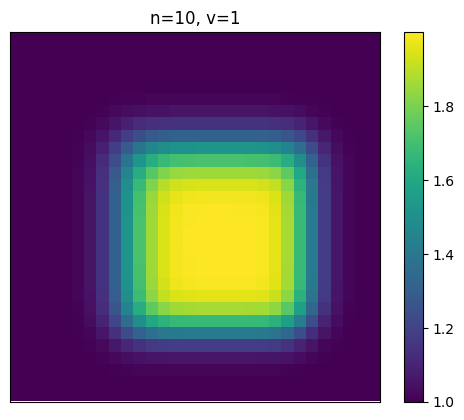

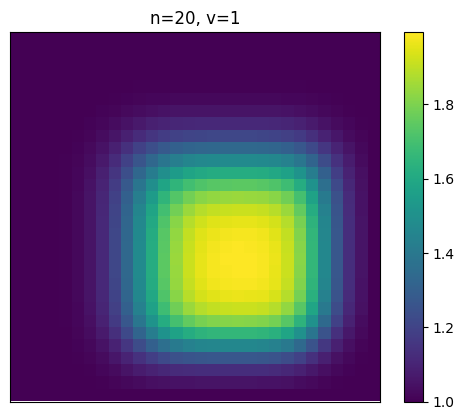

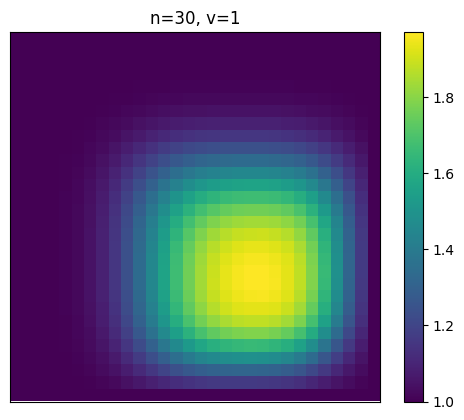

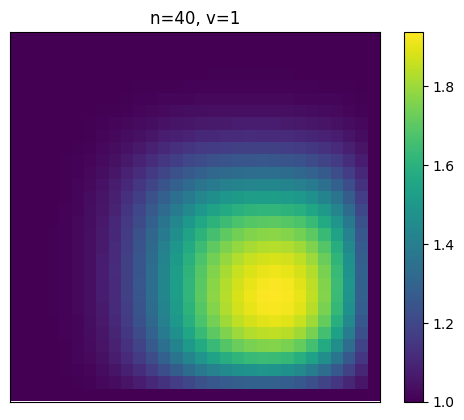

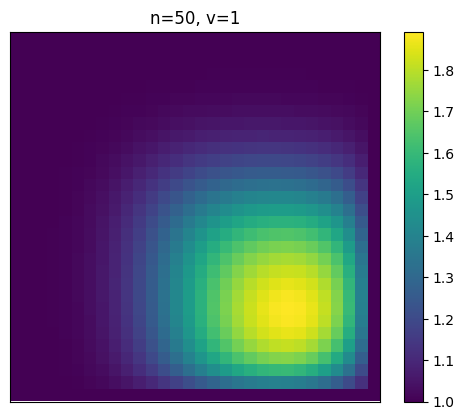

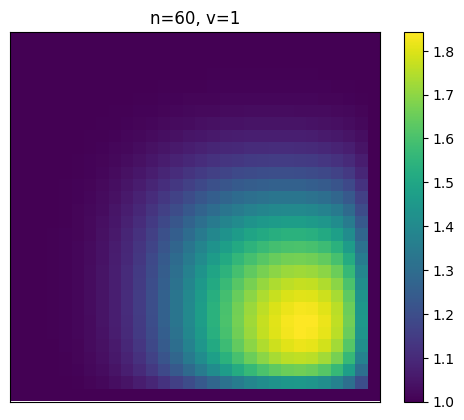

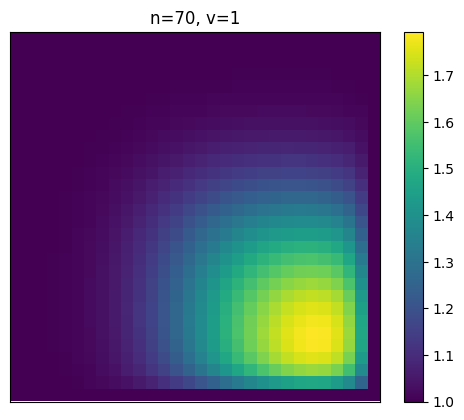

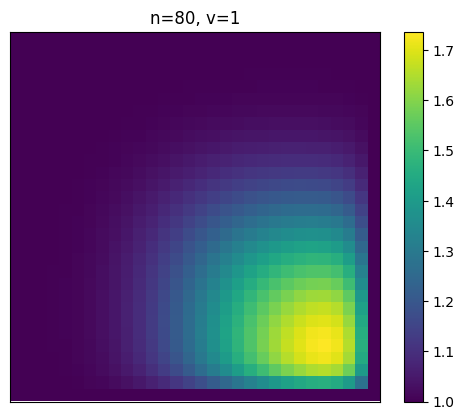

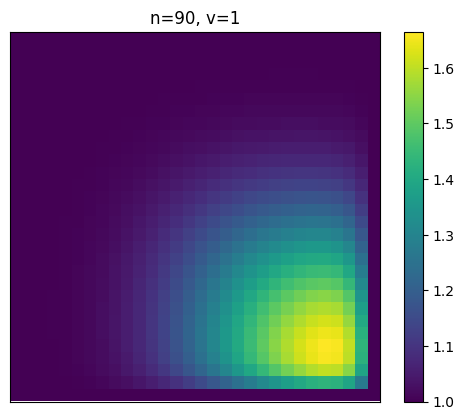

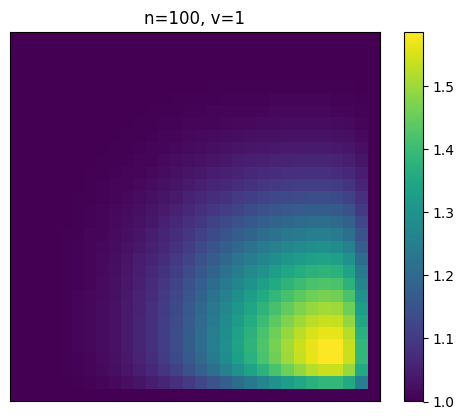

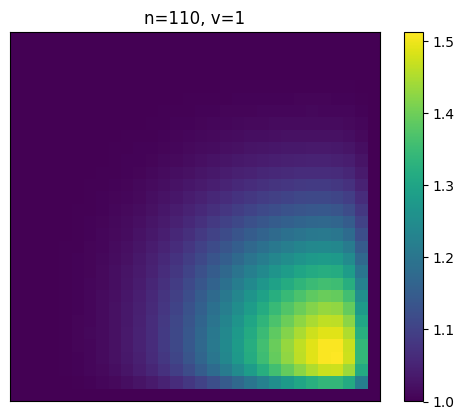

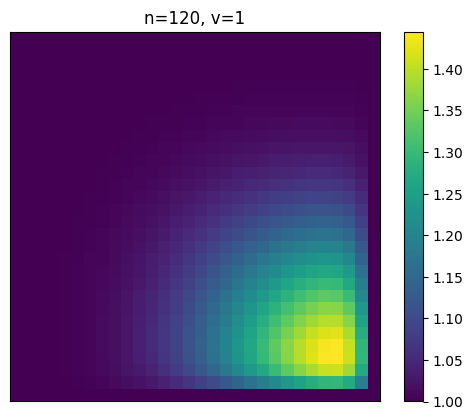

In [ ]:
burgers(120, v=1)

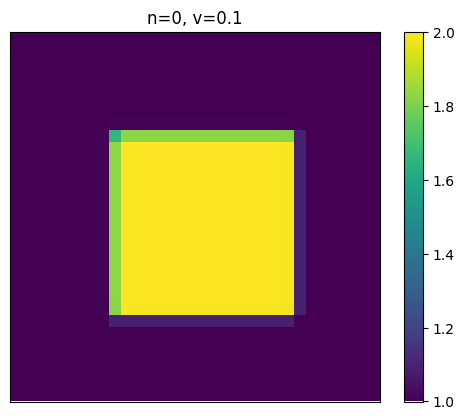

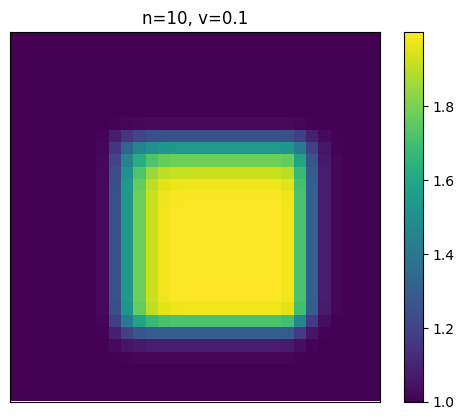

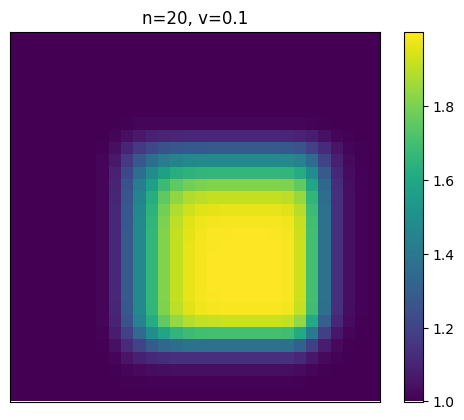

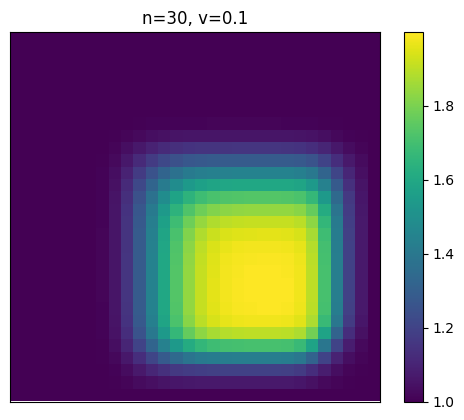

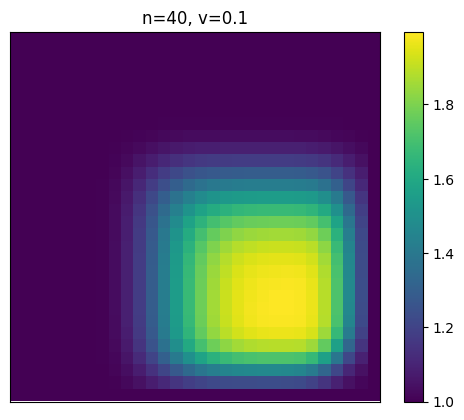

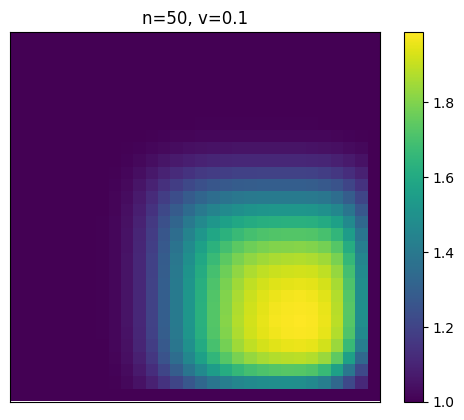

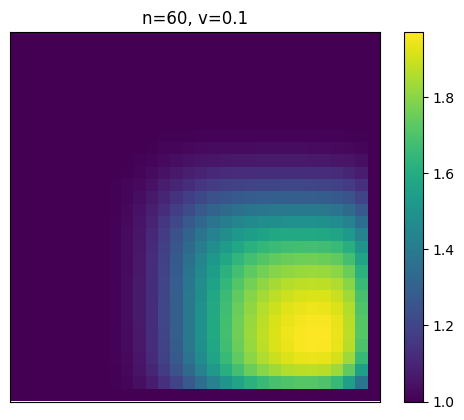

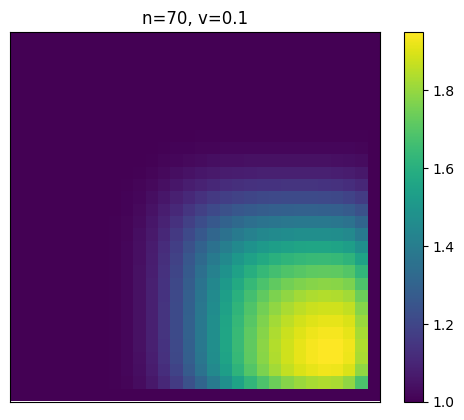

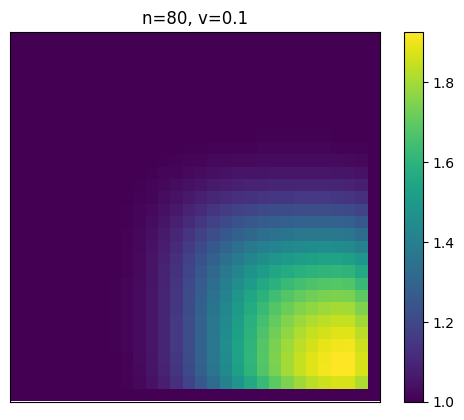

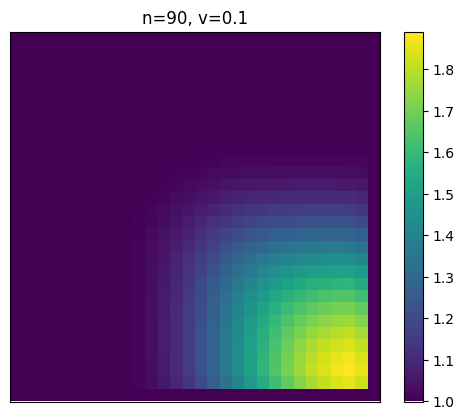

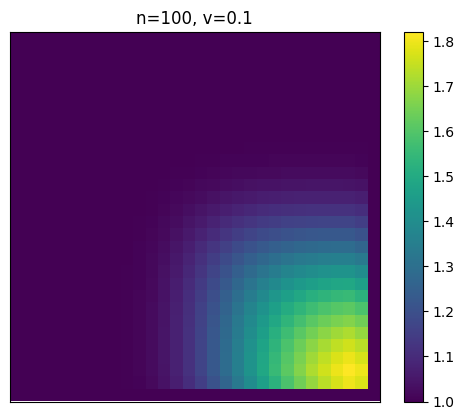

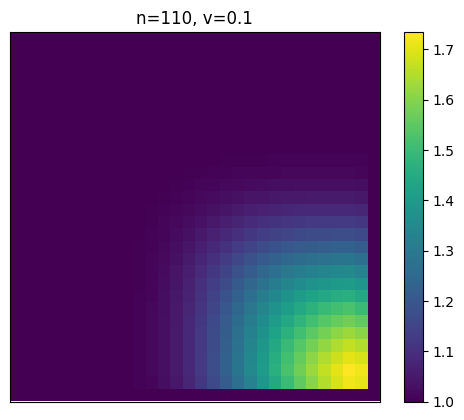

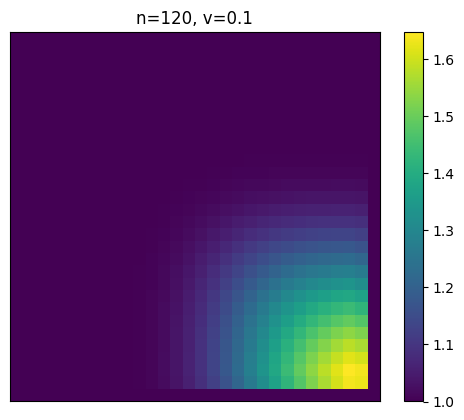

In [ ]:
burgers(120, v=0.1)